In [11]:
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from gp import train

np, sklearn, plt, train

(<module 'numpy' from 'c:\\Users\\leoli\\Documents\\GitHub\\package_stress\\.venv\\Lib\\site-packages\\numpy\\__init__.py'>,
 <module 'sklearn' from 'c:\\Users\\leoli\\Documents\\GitHub\\package_stress\\.venv\\Lib\\site-packages\\sklearn\\__init__.py'>,
 <module 'matplotlib.pyplot' from 'c:\\Users\\leoli\\Documents\\GitHub\\package_stress\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>,
 <function gp.train(X_scaled, y_scaled, kernel_class=<class 'gpytorch.kernels.linear_kernel.LinearKernel'>, training_iter=150, uniform: bool = True, noisy: bool = True, random_restart: bool = True)>)

In [12]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

In [13]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2548.07
Coefficient of determination: 0.47


In [15]:
import torch

X_scaled = torch.tensor((X_train - X_train.min()) / (X_train.max() - X_train.min()))

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
y_scaled = torch.tensor(scaler.fit_transform(y_train.reshape(-1, 1)))


In [17]:
model, likelihood = train(
    X_scaled=X_scaled,
    y_scaled=y_scaled,
    # kernel_class=...,
    # training_iter=...,
    # uniform=...,
    noisy=False,
    # random_restart=...,
)

In [18]:
X_plot = torch.linspace(0, 1, 100)

In [19]:
model.eval()
with torch.no_grad():
    observed_pred_plot = likelihood(model(X_plot))
    y_plot = scaler.inverse_transform(observed_pred_plot.mean[:, None])
    lb = scaler.inverse_transform(
        (observed_pred_plot.mean - 2 * observed_pred_plot.stddev)[:, None]
    )
    ub = scaler.inverse_transform(
        (observed_pred_plot.mean + 2 * observed_pred_plot.stddev)[:, None]
    )


Text(0.5, 1.0, 'Gaussian process regression')

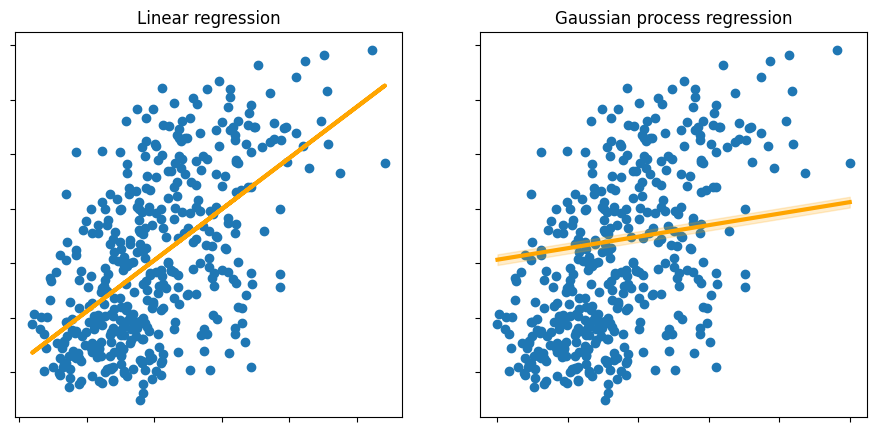

In [20]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(11, 5), sharey=True)

ax = axs[0]

ax.scatter(X_train, y_train, label="Train data points")
ax.plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="orange",
    label="Model predictions",
)
# ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
# ax[0].legend()

# ax[1].scatter(X_test, y_test, label="Test data points")
# ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
# ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
# ax[1].legend()

ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_title("Linear regression")

ax = axs[1]

ax.scatter(
    X_scaled,
    y_train,
    label="Training data",
)

p = ax.plot(
    X_plot,
    y_plot,
    label="Pred. mean",
    color="orange",
    linewidth=3,
)
color = p[0].get_color()
ax.fill_between(
    X_plot.flatten(),
    lb.flatten(),
    ub.flatten(),
    alpha=0.2,
    label="Pred. 95% CI",
    color=color,
)
# ax.set_ylabel("y")

ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_title("Gaussian process regression")
